In [450]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [451]:
dataset = os.path.join('datasets', 'loans.csv')
df = pd.read_csv(dataset, index_col='client_id')
df

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
client_id,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
...,...,...,...,...,...,...,...
26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65


In [452]:
df.shape

(443, 7)

In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 46109 to 26945
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   loan_type    443 non-null    object 
 1   loan_amount  443 non-null    int64  
 2   repaid       443 non-null    int64  
 3   loan_id      443 non-null    int64  
 4   loan_start   443 non-null    object 
 5   loan_end     443 non-null    object 
 6   rate         443 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 27.7+ KB


In [454]:
df.dtypes

loan_type       object
loan_amount      int64
repaid           int64
loan_id          int64
loan_start      object
loan_end        object
rate           float64
dtype: object

In [455]:
df['loan_id'] = df['loan_id'].astype('object')
df['repaid'] = df['repaid'].astype('category')
df.dtypes

loan_type        object
loan_amount       int64
repaid         category
loan_id          object
loan_start       object
loan_end         object
rate            float64
dtype: object

In [456]:
df['loan_start'] = pd.to_datetime(df['loan_start'], format='%Y-%m-%d')
df['loan_end'] = pd.to_datetime(df['loan_end'], format='%Y-%m-%d')
df.dtypes

loan_type              object
loan_amount             int64
repaid               category
loan_id                object
loan_start     datetime64[ns]
loan_end       datetime64[ns]
rate                  float64
dtype: object

In [457]:
df.describe(include=[np.number])

,loan_amount,rate
count,443.000000,443.000000
mean,7982.311512,3.217156
std,4172.891992,2.397168
min,559.000000,0.010000
25%,4232.500000,1.220000
50%,8320.000000,2.780000
75%,11739.000000,4.750000
max,14971.000000,12.620000


In [458]:
df.describe(exclude=[np.number])

,loan_type,repaid,loan_id,loan_start,loan_end
count,443,443.0,443.0,443,443
unique,4,2.0,443.0,NaN,NaN
top,home,1.0,10243.0,NaN,NaN
freq,121,237.0,1.0,NaN,NaN
mean,NaN,NaN,NaN,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536
min,NaN,NaN,NaN,2000-01-26 00:00:00,2001-08-02 00:00:00
25%,NaN,NaN,NaN,2003-10-19 00:00:00,2005-09-12 12:00:00
50%,NaN,NaN,NaN,2007-03-10 00:00:00,2009-03-19 00:00:00
75%,NaN,NaN,NaN,2011-07-31 00:00:00,2013-09-11 12:00:00
max,NaN,NaN,NaN,2014-11-11 00:00:00,2017-05-07 00:00:00


In [459]:
df.isnull().sum()

loan_type      0
loan_amount    0
repaid         0
loan_id        0
loan_start     0
loan_end       0
rate           0
dtype: int64

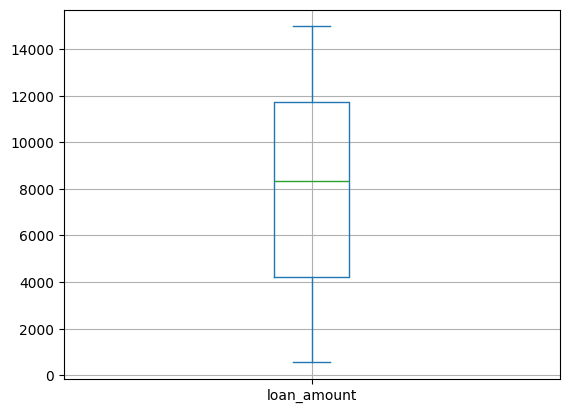

In [460]:
df['loan_amount'].plot(kind='box')
plt.grid()

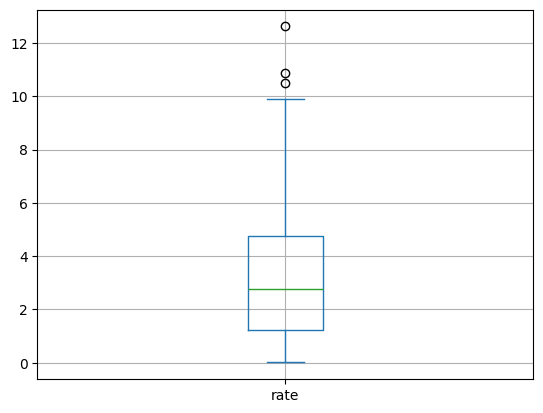

In [461]:
df['rate'].plot(kind='box')
plt.grid()

In [462]:
df['sqrt_rate'] = df['rate'] ** 0.5
df['sqrt_rate'] = np.sqrt(df['rate'])
df

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,sqrt_rate
client_id,,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,1.466288
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,1.118034
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,0.824621
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,1.113553
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,1.769181
...,...,...,...,...,...,...,...,...
26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,1.568439
26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,2.295648
26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,2.376973


In [463]:
print(f'Skewness of the rate : {df.rate.skew()}')
print(f'Skewness of the sqrt rate : {df.sqrt_rate.skew()}')
print()
print(f'Kurtosis of the rate : {df.rate.kurtosis()}')
print(f'Kurtosis of the sqrt rate : {df.sqrt_rate.kurtosis()}')

Skewness of the rate : 0.884204614329943
Skewness of the sqrt rate : 0.04964154055528862

Kurtosis of the rate : 0.4243716514373652
Kurtosis of the sqrt rate : -0.6318437642052039


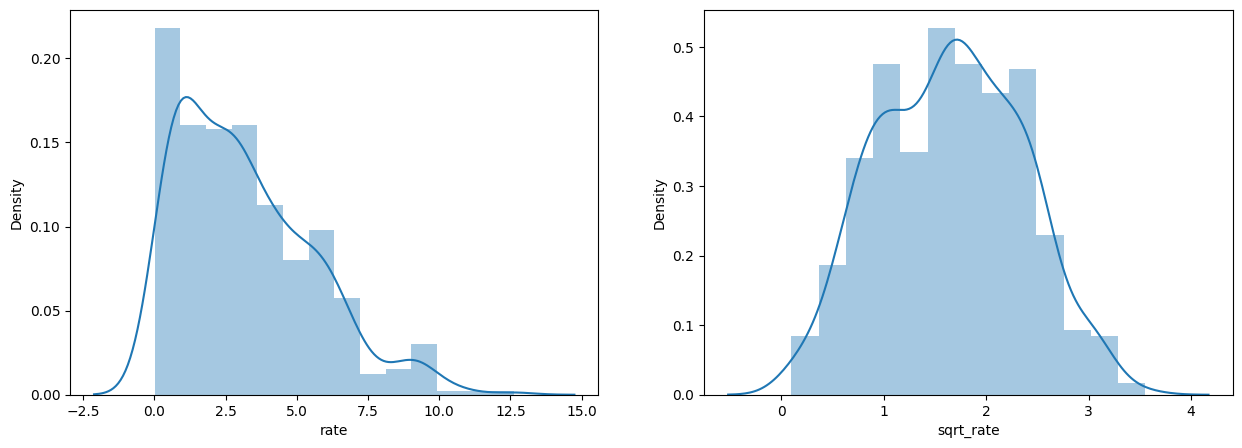

In [464]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.distplot(df['rate'], ax=ax[0])
sns.distplot(df['sqrt_rate'], ax=ax[1])
plt.show()

In [465]:
df['log_rate'] = df['rate'].apply(lambda x: np.log(x))
df['log_rate'] = np.log(df['rate'])
df

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,sqrt_rate,log_rate
client_id,,,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,1.466288,0.765468
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,1.118034,0.223144
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,0.824621,-0.385662
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,1.113553,0.215111
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,1.769181,1.141033
...,...,...,...,...,...,...,...,...,...
26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,1.568439,0.900161
26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,2.295648,1.662030
26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,2.376973,1.731656


In [466]:
print(f'Skewness of the rate : {df.rate.skew()}')
print(f'Skewness of the sqrt rate : {df.sqrt_rate.skew()}')
print(f'Skewness of the log rate : {df.log_rate.skew()}')
print()
print(f'Kurtosis of the rate : {df.rate.kurtosis()}')
print(f'Kurtosis of the sqrt rate : {df.sqrt_rate.kurtosis()}')
print(f'Kurtosis of the log rate : {df.log_rate.kurtosis()}')

Skewness of the rate : 0.884204614329943
Skewness of the sqrt rate : 0.04964154055528862
Skewness of the log rate : -1.5943217626331552

Kurtosis of the rate : 0.4243716514373652
Kurtosis of the sqrt rate : -0.6318437642052039
Kurtosis of the log rate : 4.157026150198228


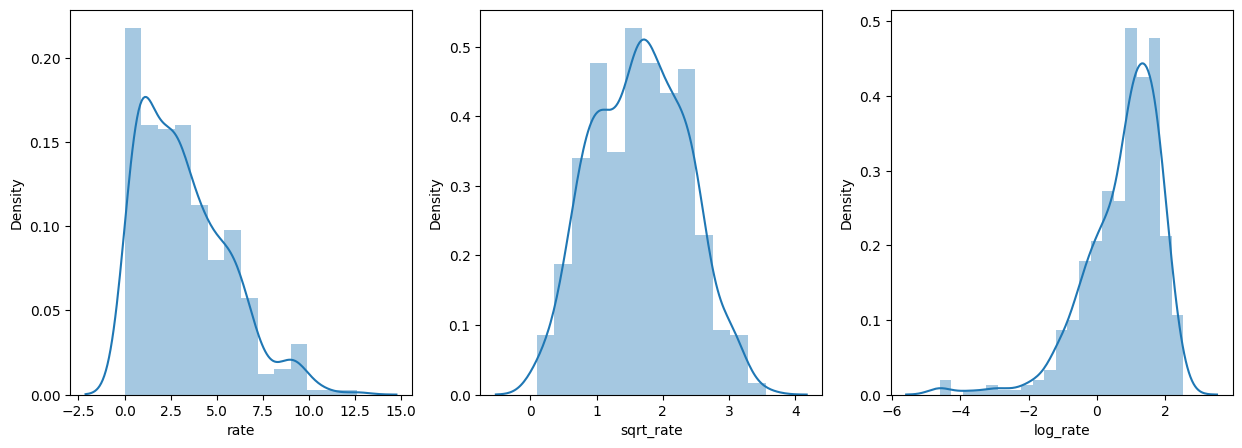

In [467]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.distplot(df['rate'], ax=ax[0])
sns.distplot(df['sqrt_rate'], ax=ax[1])
sns.distplot(df['log_rate'], ax=ax[2])
plt.show()

In [468]:
dataset = os.path.join('datasets', 'loans.csv')
df = pd.read_csv(dataset, index_col='client_id')
df

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
client_id,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
...,...,...,...,...,...,...,...
26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65


In [469]:
df['loan_id'] = df['loan_id'].astype('object')
df['repaid'] = df['repaid'].astype('category')
df.dtypes

loan_type        object
loan_amount       int64
repaid         category
loan_id          object
loan_start       object
loan_end         object
rate            float64
dtype: object

In [470]:
df['loan_start'] = pd.to_datetime(df['loan_start'], format='%Y-%m-%d')
df['loan_end'] = pd.to_datetime(df['loan_end'], format='%Y-%m-%d')
df.dtypes

loan_type              object
loan_amount             int64
repaid               category
loan_id                object
loan_start     datetime64[ns]
loan_end       datetime64[ns]
rate                  float64
dtype: object

In [471]:
df['ZR'] = stats.zscore(df['rate'])
df

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,ZR
client_id,,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,-0.445677
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,-0.821544
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,-1.059594
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,-0.825721
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,-0.036399
...,...,...,...,...,...,...,...,...
26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,-0.316211
26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,0.857331
26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,1.016030


In [472]:
df[(df['ZR'] < -3) | (df['ZR'] > 3)]

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,ZR
client_id,,,,,,,,
41480,credit,2947,1,10302,2005-11-10,2008-03-16,10.49,3.037362
48177,other,6318,0,10224,2003-02-02,2005-05-08,10.89,3.204415
49624,home,8133,1,10312,2009-03-14,2011-03-21,12.62,3.926916


In [473]:
df[(df['ZR'] < -3) | (df['ZR'] > 3)].shape[0]

3

In [474]:
df.shape

(443, 8)

In [475]:
df2 = df[(df['ZR'] > -3) & (df['ZR'] < 3)].reset_index()
df2

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,ZR
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,-0.445677
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,-0.821544
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,-1.059594
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,-0.825721
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,-0.036399
...,...,...,...,...,...,...,...,...,...
435,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,-0.316211
436,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,0.857331
437,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,1.016030
438,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50,0.535755


In [476]:
df2.shape

(440, 9)

In [477]:
df3 = df2.copy()
df3.drop('ZR', axis=1, inplace=True)
df3

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
...,...,...,...,...,...,...,...,...
435,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
436,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
437,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65
438,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50


In [478]:
Q1 = df3.rate.quantile(0.25)
Q2 = df3.rate.quantile(0.5)
Q3 = df3.rate.quantile(0.75)

IQR = Q3 - Q1

LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)

display(LC)
display(UC)

np.float64(-3.9762499999999994)

np.float64(9.87375)

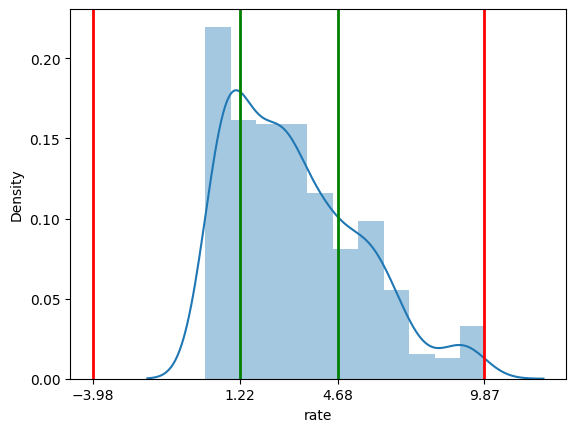

In [479]:
sns.distplot(df3.rate)
plt.axvline(UC, color='r', lw=2)
plt.axvline(LC, color='r', lw=2)
plt.axvline(Q1, color='g', lw=2)
plt.axvline(Q3, color='g', lw=2)
plt.xticks([LC, Q1, Q3, UC])
plt.show()

In [480]:
df3[(df3.rate < LC) | (df3.rate > UC)].reset_index(drop=True)

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,39505,cash,11647,1,11928,2003-07-28,2005-12-24,9.91


In [481]:
df3[(df3.rate < LC) | (df3.rate > UC)].shape[0]

1

In [482]:
df3.shape

(440, 8)

In [483]:
df4 = df3[(df3.rate > LC) & (df3.rate < UC)]
df4

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
...,...,...,...,...,...,...,...,...
435,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
436,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
437,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65
438,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50


In [484]:
df4.shape

(439, 8)

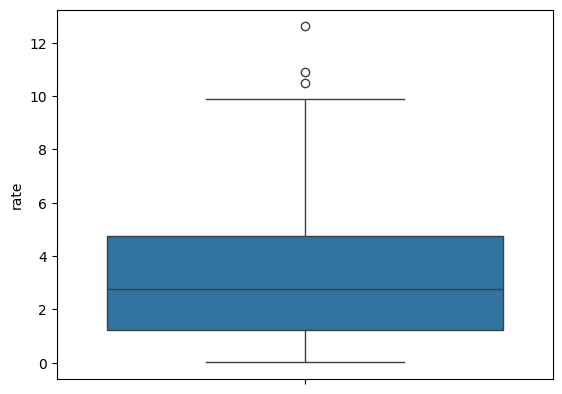

In [485]:
sns.boxplot(df.rate);

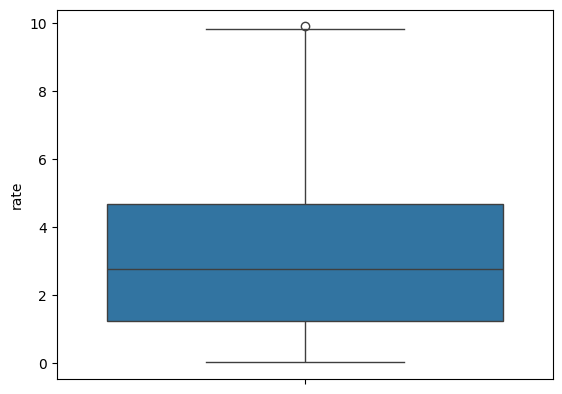

In [486]:
sns.boxplot(df2.rate);

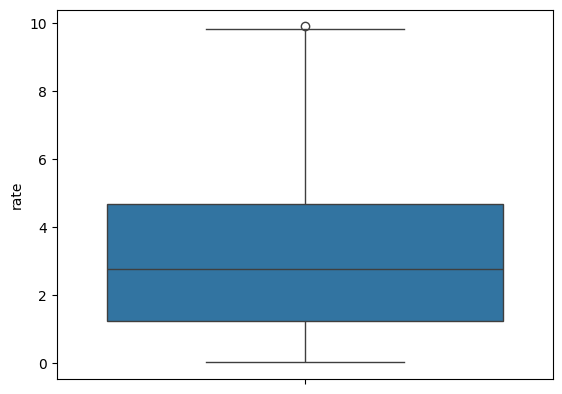

In [487]:
sns.boxplot(df3.rate);

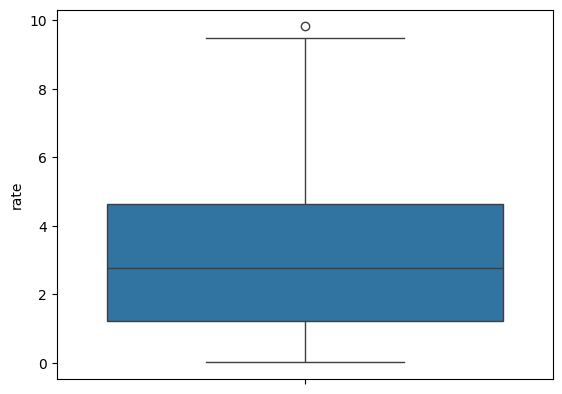

In [488]:
sns.boxplot(df4.rate);

In [489]:
avg_rate = df3['rate'].mean()
avg_rate

np.float64(3.161818181818182)

In [490]:
std_rate = df3['rate'].std()
std_rate

np.float64(2.3079474188229154)

In [491]:
df3['z_score_rate'] = (df3['rate'] - avg_rate) / std_rate
df3

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,z_score_rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,-0.438406
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,-0.828363
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,-1.075336
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,-0.832696
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,-0.013786
...,...,...,...,...,...,...,...,...,...
435,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,-0.304088
436,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,0.913444
437,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,1.078093
438,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50,0.579815


In [493]:
print(f'Skewness of the rate : {df3.rate.skew()}')
print(f'Skewness of the z score rate : {df3.z_score_rate.skew()}')
print()
print(f'Kurtosis of the rate : {df3.rate.kurtosis()}')
print(f'Kurtosis of the z score rate : {df3.z_score_rate.kurtosis()}')

Skewness of the rate : 0.7594062707815686
Skewness of the z score rate : 0.7594062707815691

Kurtosis of the rate : -0.05964248048746912
Kurtosis of the z score rate : -0.05964248048746823


In [494]:
avg_la = df3['loan_amount'].mean()
avg_la

np.float64(7997.195454545455)

In [495]:
std_la = df3['loan_amount'].std()
std_la

np.float64(4179.435966237437)

In [496]:
df3['z_score_la'] = (df3['loan_amount'] - avg_la) / std_la
df3

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,z_score_rate,z_score_la
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,-0.438406,1.357792
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,-0.828363,0.429916
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,-1.075336,1.133360
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,-0.832696,1.081678
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,-0.013786,1.447996
...,...,...,...,...,...,...,...,...,...,...
435,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46,-0.304088,1.188152
436,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27,0.913444,-1.500010
437,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65,1.078093,0.318657
438,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50,0.579815,-0.909260


In [497]:
print(f'Skewness of the loan amount : {df3.loan_amount.skew()}')
print(f'Skewness of the z score loan amount : {df3.z_score_la.skew()}')
print()
print(f'Kurtosis of the loan amount : {df3.loan_amount.kurtosis()}')
print(f'Kurtosis of the z score loan amount : {df3.z_score_la.kurtosis()}')

Skewness of the loan amount : -0.04678765472024289
Skewness of the z score loan amount : -0.04678765472024289

Kurtosis of the loan amount : -1.2354309429278456
Kurtosis of the z score loan amount : -1.2354309429278456


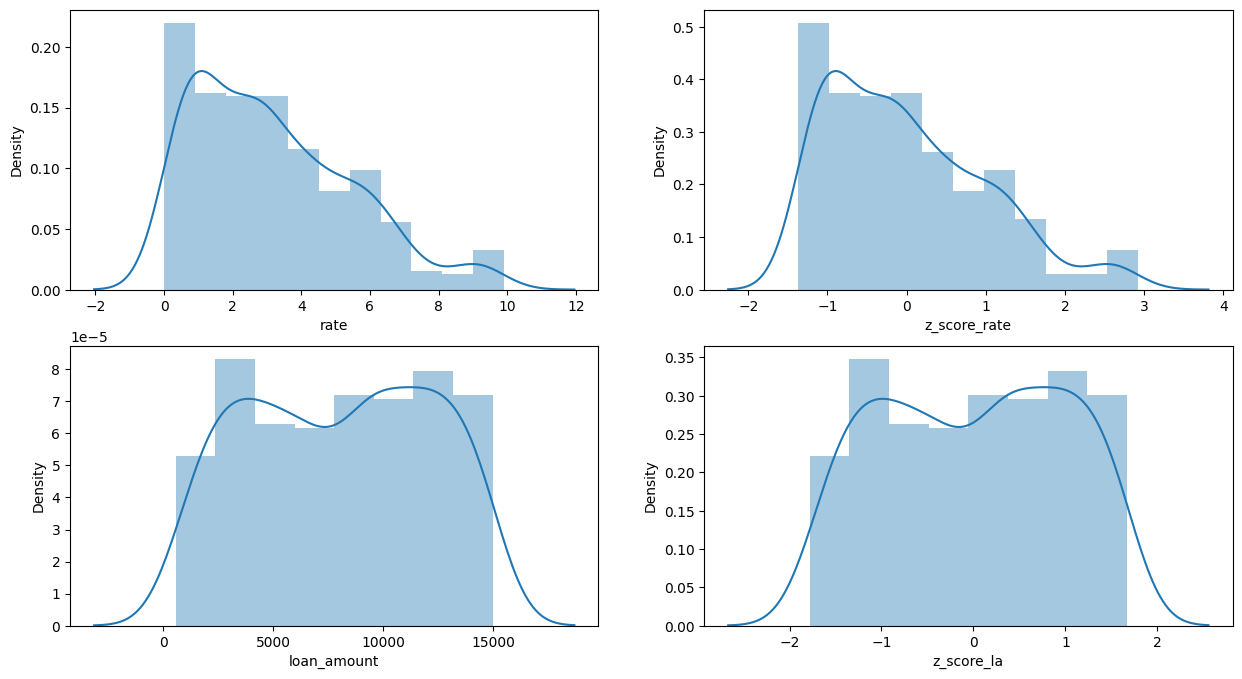

In [498]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
sns.distplot(df3['rate'], ax=ax[0,0])
sns.distplot(df3['z_score_rate'], ax=ax[0,1])
sns.distplot(df3['loan_amount'], ax=ax[1,0])
sns.distplot(df3['z_score_la'], ax=ax[1,1])
plt.show()